In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [34]:
import pandas as pd


In [35]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [37]:
df.isnull().sum()


id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
# Assuming your dataset is loaded into a Pandas DataFrame called 'df'
df = df.drop('id', axis=1)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [40]:
# Check what the actual values are first
print(df['Churn'].unique())


['No' 'Yes']


In [41]:

# If they are 'Yes' and 'No', map them to 1 and 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [42]:
print(df['Churn'].unique())


[0 1]


In [43]:
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    77.479241
1    22.520759
Name: proportion, dtype: float64


categorical features uniqe value

In [44]:
# Only print unique values for text/categorical columns
for column in df.select_dtypes(include=['object']).columns:
    print(f"--- {column} ---")
    print(df[column].unique())
    print("\n")

--- gender ---
['Male' 'Female']


--- Partner ---
['Yes' 'No']


--- Dependents ---
['Yes' 'No']


--- PhoneService ---
['Yes' 'No']


--- MultipleLines ---
['No' 'Yes' 'No phone service']


--- InternetService ---
['DSL' 'Fiber optic' 'No']


--- OnlineSecurity ---
['Yes' 'No' 'No internet service']


--- OnlineBackup ---
['No' 'Yes' 'No internet service']


--- DeviceProtection ---
['Yes' 'No' 'No internet service']


--- TechSupport ---
['Yes' 'No' 'No internet service']


--- StreamingTV ---
['No' 'Yes' 'No internet service']


--- StreamingMovies ---
['No' 'Yes' 'No internet service']


--- Contract ---
['One year' 'Two year' 'Month-to-month']


--- PaperlessBilling ---
['Yes' 'No']


--- PaymentMethod ---
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']




## Visualization

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: This makes your charts look a bit cleaner
sns.set_theme(style="whitegrid")

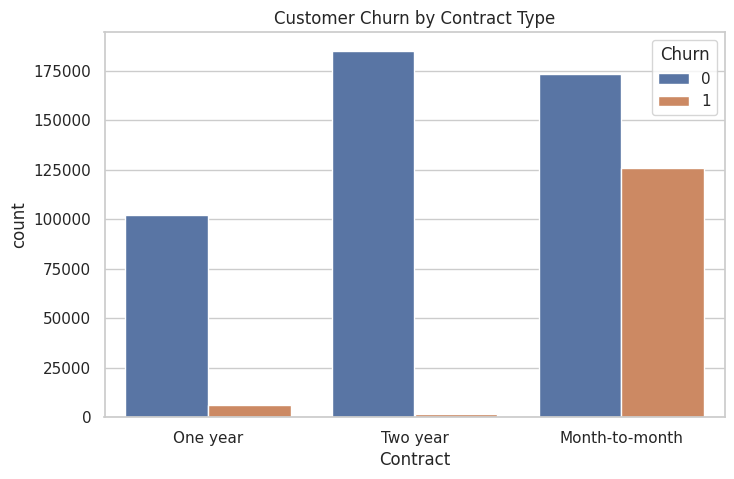

In [46]:
plt.figure(figsize=(8, 5))
# We use 'hue' to split the bars by who churned (1) and who stayed (0)
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Customer Churn by Contract Type')
plt.show()

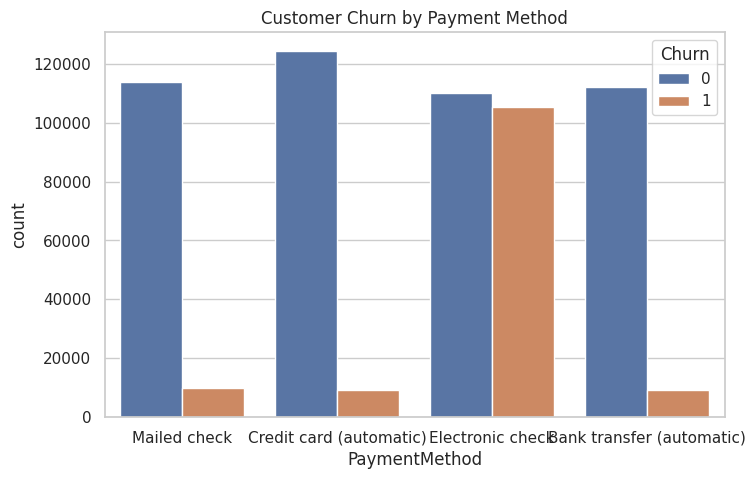

In [47]:
plt.figure(figsize=(8, 5))
# We use 'hue' to split the bars by who churned (1) and who stayed (0)
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Customer Churn by Payment Method')
plt.show()

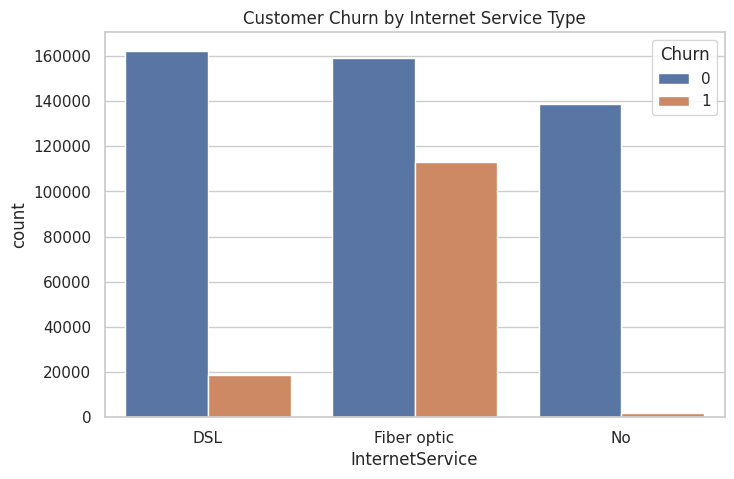

In [48]:
plt.figure(figsize=(8, 5))
# We use 'hue' to split the bars by who churned (1) and who stayed (0)
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Customer Churn by Internet Service Type')
plt.show()

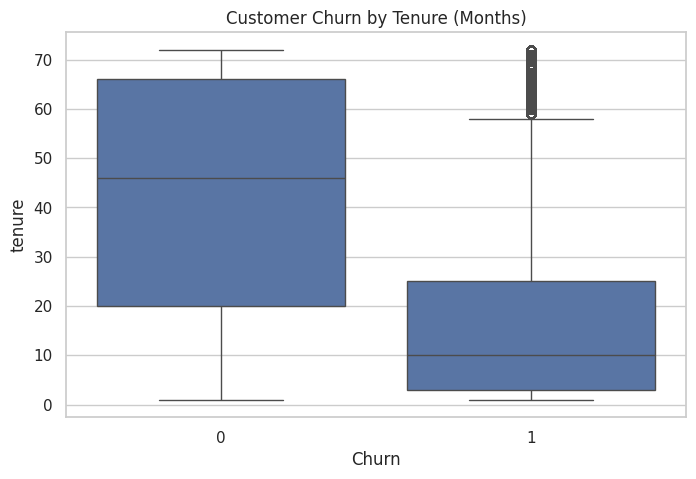

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Customer Churn by Tenure (Months)')
plt.show()

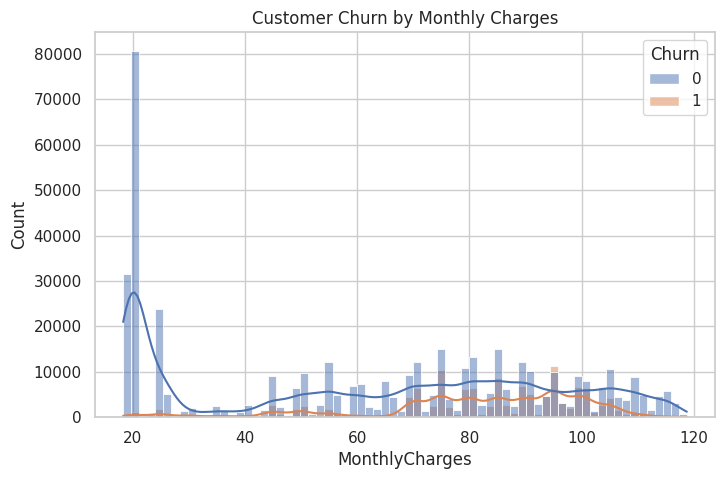

In [50]:
plt.figure(figsize=(8, 5))
# KDE adds a smooth trendline over the bars
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title('Customer Churn by Monthly Charges')
plt.show()

In [51]:
import pandas as pd

# 1. Map the binary text columns to 0 and 1
binary_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# 2. Let Pandas One-Hot Encode all the remaining text columns (like Contract, InternetService, etc.)
# Pandas is smart enough to only target the 'object' (text) columns automatically!
df = pd.get_dummies(df, drop_first=True)

# Look at your beautiful, 100% numerical dataset!
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           1      29             1   
1       0              0        1           1      58             1   
2       0              0        1           0      58             1   
3       1              0        0           0       1             1   
4       1              0        0           0       1             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           60.10       1653.85      0  ...   
1                 0           69.50       3778.20      0  ...   
2                 1          100.40       5841.35      0  ...   
3                 1           69.70         70.70      1  ...   
4                 1           70.45         70.45      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0             True                            False            False   
1             True                    

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 31 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   gender                                 594194 non-null  int64  
 1   SeniorCitizen                          594194 non-null  int64  
 2   Partner                                594194 non-null  int64  
 3   Dependents                             594194 non-null  int64  
 4   tenure                                 594194 non-null  int64  
 5   PhoneService                           594194 non-null  int64  
 6   PaperlessBilling                       594194 non-null  int64  
 7   MonthlyCharges                         594194 non-null  float64
 8   TotalCharges                           594194 non-null  float64
 9   Churn                                  594194 non-null  int64  
 10  MultipleLines_No phone service         594194 non-null  

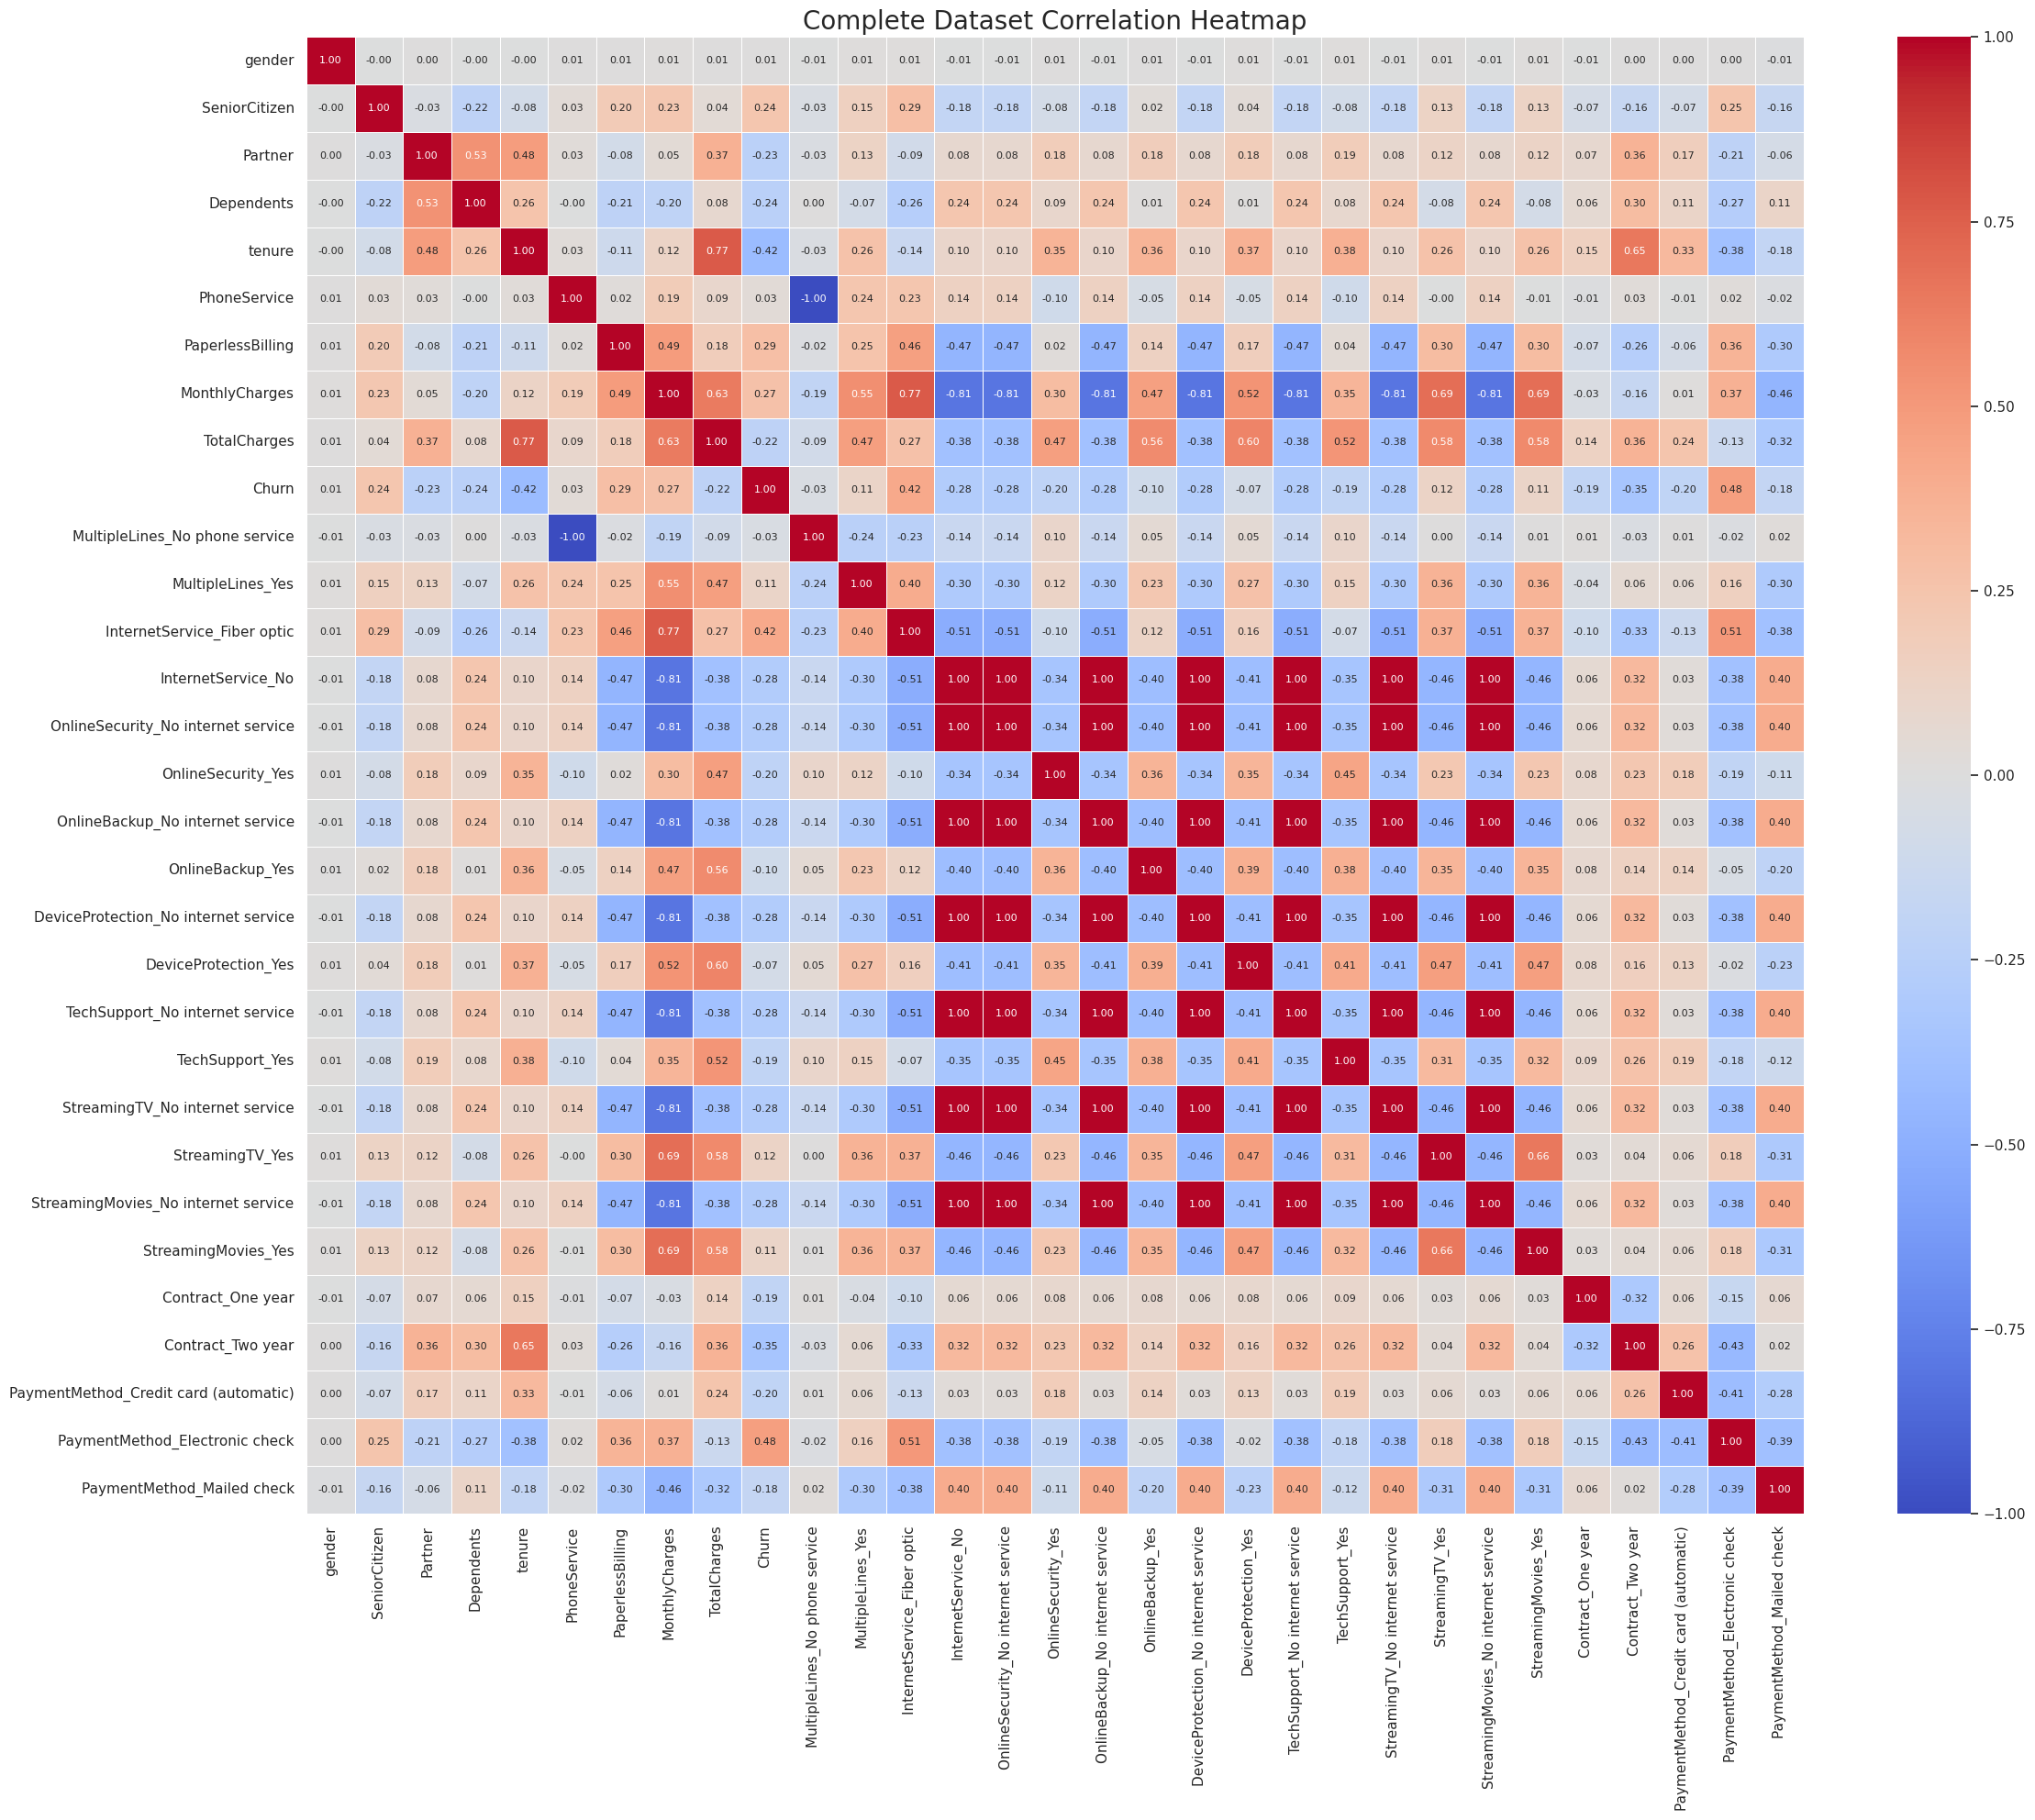

In [53]:

# --- 2. PLOTTING THE HEATMAP ---
# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up a MASSIVE figure size so we can read it
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Prints the numbers
            fmt=".2f",           # Rounds to 2 decimal places
            cmap='coolwarm',     # Red = Positive correlation, Blue = Negative
            linewidths=0.5, 
            annot_kws={"size": 8}) # Makes the font size a bit smaller to fit

plt.title('Complete Dataset Correlation Heatmap', fontsize=20)
plt.tight_layout() # Keeps labels from getting cut off
plt.show()

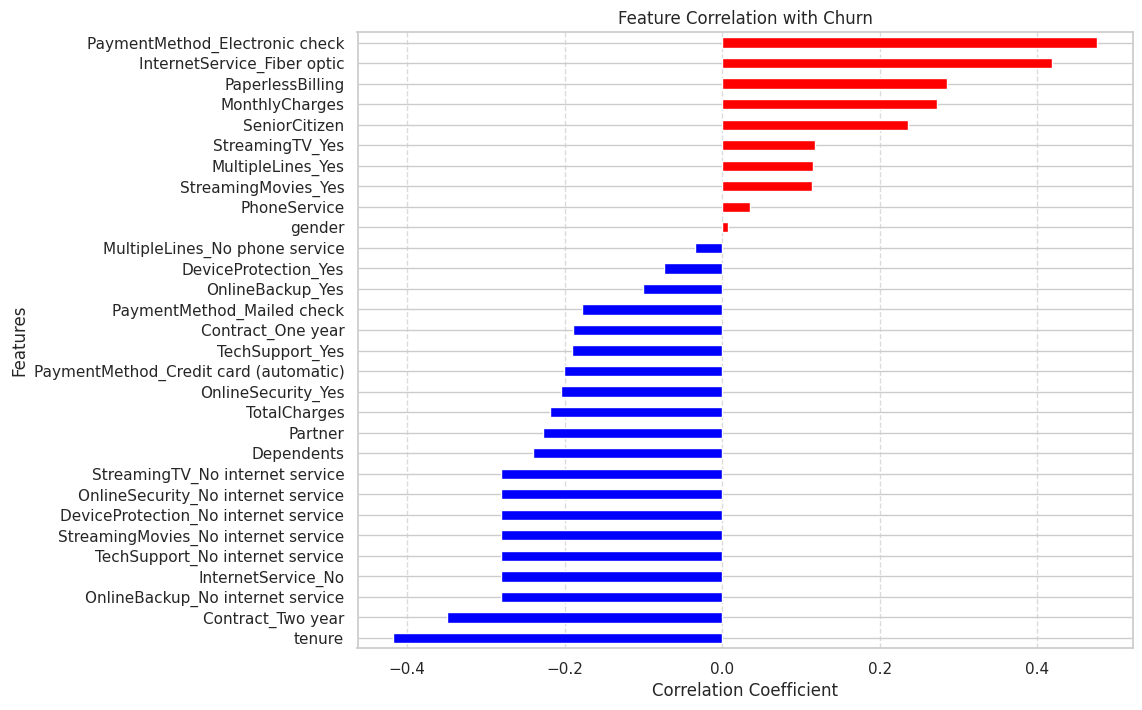

In [54]:
plt.figure(figsize=(10, 8))

# Get correlations ONLY for the 'Churn' column, drop Churn itself, and sort them
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values()

# Create a bar plot
churn_corr.plot(kind='barh', color=churn_corr.map(lambda x: 'red' if x > 0 else 'blue'))

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()